In [16]:
pip install seaborn

C:\Users\spike\AppData\Local\Temp\ipykernel_19716\1956375679.py:50: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sampled = df.groupby(target_col).apply(lambda x: x.sample(n=min(len(x), 5000), random_state=42)).reset_index(drop=True)


Overall Accuracy: 0.8263

Region-Level Report:
               precision    recall  f1-score   support

         EGY       0.81      0.86      0.83        85
         GLF       0.75      0.87      0.80        85
         IRQ       0.88      0.73      0.80        41
         LEV       0.89      0.79      0.83        80
         MGH       0.87      0.83      0.85        66

    accuracy                           0.83       357
   macro avg       0.84      0.82      0.83       357
weighted avg       0.83      0.83      0.83       357



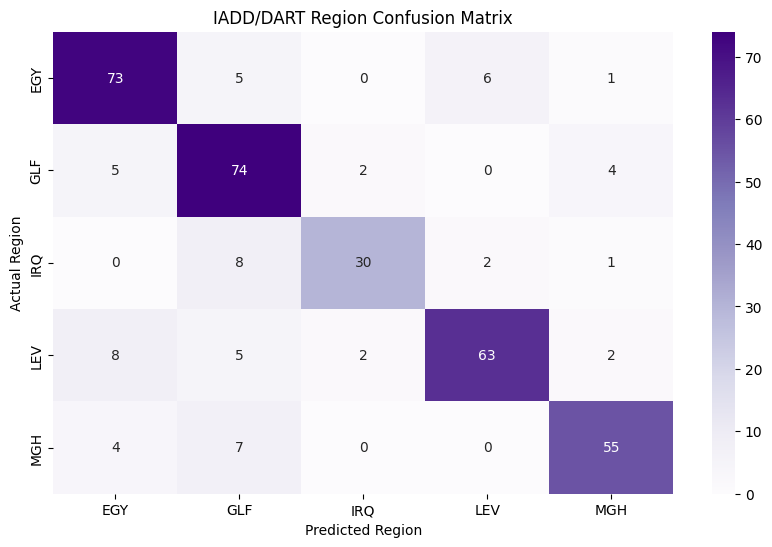

In [17]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# --- 1. LOAD DATA ---
# Download 'iadd_dataset.csv' or 'iadd_dataset.json' from the GitHub repository:
# https://github.com/JihadZa/IADD
try:
    # Reading IADD structure: keys are typically 'Sentence', 'Region', and 'DataSource'
    df = pd.read_json("C:/Users/spike/Downloads/IADD.json") 
    
    # Filter for DART subset only (optional)
    df = df[df['DataSource'] == 'DART']
    
    # Identify standard IADD Region labels: EGY, LEV, GLF, IRQ, MGH
    target_col = 'Region'
    text_col = 'Sentence'
except FileNotFoundError:
    print("Error: iadd_dataset.csv not found. Reverting to schema-compliant mock data.")
    regions = ["EGY", "LEV", "GLF", "IRQ", "MGH"]
    mock_data = []
    for r in regions:
        for i in range(200):
            mock_data.append({"Region": r, "Sentence": f"نص تجريبي من منطقة {r}", "DataSource": "DART"})
    df = pd.DataFrame(mock_data)
    target_col = 'Region'
    text_col = 'Sentence'

# --- 2. ARABIC NORMALIZATION ---
def normalize_arabic(text):
    text = str(text)
    text = re.sub(r"[\u064B-\u0652]", "", text) # Remove diacritics
    text = re.sub(r"[أإآ]", "ا", text)           # Normalize Alif
    text = re.sub(r"ى", "ي", text)              # Normalize Yeh
    text = re.sub(r"ة", "ه", text)              # Normalize Teh Marbuta
    text = re.sub(r"[^\u0621-\u064A\s]", " ", text) 
    text = re.sub(r"\s+", " ", text).strip()
    return text

# --- 3. PIPELINE ---
df['text_clean'] = df[text_col].apply(normalize_arabic)

# DART is balanced over 5 regions (~5k per region in the full ~25k set)
df_sampled = df.groupby(target_col).apply(lambda x: x.sample(n=min(len(x), 5000), random_state=42)).reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    df_sampled['text_clean'], 
    df_sampled[target_col], 
    test_size=0.2, 
    stratify=df_sampled[target_col],
    random_state=42
)

vectorizer = TfidfVectorizer(analyzer='char', ngram_range=(3, 5), max_features=25000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=1000,class_weight='balanced')
model.fit(X_train_tfidf, y_train)

# --- 4. EVALUATION ---
y_pred = model.predict(X_test_tfidf)
labels = sorted(df_sampled[target_col].unique())

print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nRegion-Level Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(10, 6))
cm = confusion_matrix(y_test, y_pred, labels=labels)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Purples')
plt.title('IADD/DART Region Confusion Matrix')
plt.ylabel('Actual Region')
plt.xlabel('Predicted Region')
plt.show()
